In [56]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from scipy import stats

In [57]:
df = pd.read_csv('../data/youtube/clean_dataset.csv',keep_default_na=False)

In [58]:
df.head()

,video_id,title,publishedAt,channelId,channelTitle,categoryId,tags,view_count,likes,comment_count,...,projection,embeddable,madeForKids,chapter_count,playability_status,supports_miniplayer,card_count,is_verified,has_paid_promotion,comments_disabled
0,G4M_621v1As,college farewell video#trending #viralshorts,2025-04-12T02:06:42Z,UC7k_7IF3s3TY-cowwxs_yWw,Vk_07_rider,22,"['college farewell video', 'DDU farewell video...",18.650077,14.258386,7.367709,...,rectangular,True,False,0,OK,True,1,False,False,False
1,z2voqo_Jhx4,Busking in Manchester 🇬🇧 #blindfaith #guitar #...,2025-04-06T11:35:53Z,UCM_9JHB3xXPSzJfTkD86AtA,Leonardo Patrick,10,[],18.366689,13.738122,8.674197,...,rectangular,True,False,0,OK,True,1,False,False,False
2,jHIt9oHFLsw,This is what happens when you play Star Wars i...,2025-04-06T10:07:12Z,UC4YyKY5o60Kckk-GXOnhT2g,Violin Phonix,22,[],17.941771,13.880749,8.324821,...,rectangular,True,False,0,OK,True,1,True,False,False
3,gwRqLbWqKlM,LISA - FUTW (YouTube Music Nights Special Stag...,2025-03-19T03:29:33Z,UC6-BgjsBa5R3PZQ_kZ8hKPg,LLOUD Official,10,"['Blackpink', 'Lisa', 'Music', 'Fashion', 'K-P...",16.493511,13.029847,9.923143,...,rectangular,True,False,0,OK,True,1,True,False,False
4,prpRoyrutcE,Uljhi hai yeh kis jaal me tu…. Bengaluru ❤️,2025-04-14T10:17:58Z,UCiFXnvi8ESDukE25ol2foWQ,Mr.KiranJ,10,[],17.081459,12.725664,7.755339,...,rectangular,True,False,0,OK,True,1,True,False,False


In [59]:
df["title_len"] = df["title"].apply(lambda x: len(x))
df["description_len"] = df["description"].apply(lambda x: len(x))

In [60]:
NUMERIC_COLUMNS = ["view_count", "likes", "comment_count","title_len","description_len"]
DROPPED_CATEGORICAL_COLUMNS = ['projection', "dimension", "definition",  "playability_status", "supports_miniplayer","has_paid_promotion"]
CATEGORICAL_COLUMNS = ["categoryId", "defaultLanguage",  "is_verified","caption","licensedContent",  "comments_disabled"]
TARGET_COLUMN = "is_trending"

In [61]:
df["defaultLanguage"] = df["defaultLanguage"].str.split("-").str[0]

In [62]:
df['hour'] = pd.to_datetime(df['publishedAt']).dt.hour
df['weekday'] = pd.to_datetime(df['publishedAt']).dt.weekday
df['month'] = pd.to_datetime(df['publishedAt']).dt.month
df['year'] = pd.to_datetime(df['publishedAt']).dt.year
df['quarter'] = pd.to_datetime(df['publishedAt']).dt.quarter
df['isWeekend'] = pd.to_datetime(df['publishedAt']).dt.dayofweek.isin([5, 6])

time_cols = ["hour", "weekday", "month", "quarter"]

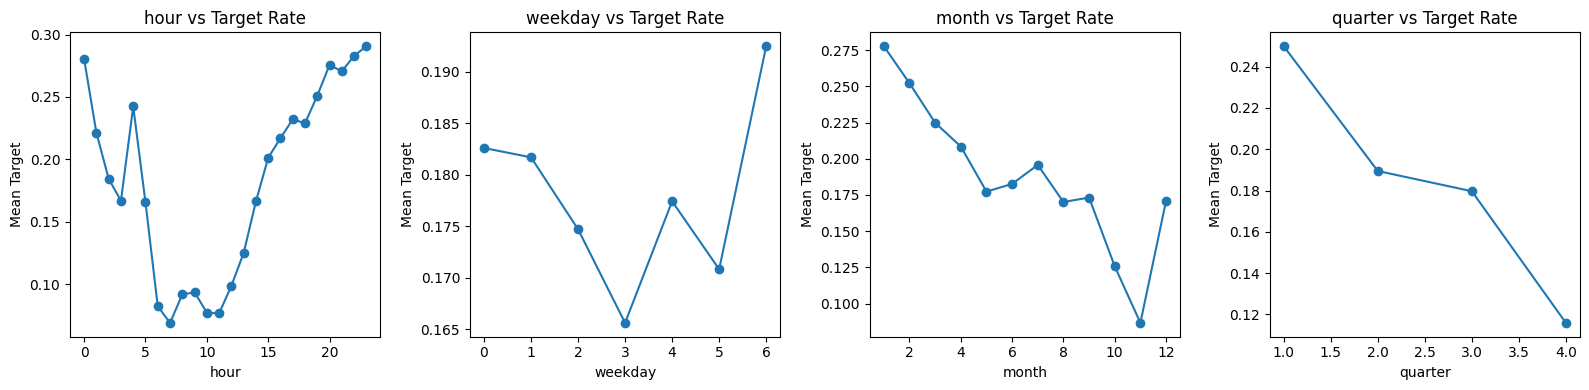

In [63]:
fig, axes = plt.subplots(1, len(time_cols), figsize=(4 * len(time_cols), 4))

for ax, col in zip(axes, time_cols):
    mean_vals = df.groupby(col)[TARGET_COLUMN].mean()
    
    ax.plot(mean_vals.index, mean_vals.values, marker='o')
    ax.set_title(f"{col} vs Target Rate")
    ax.set_xlabel(col)
    ax.set_ylabel("Mean Target")

plt.tight_layout()
plt.show()

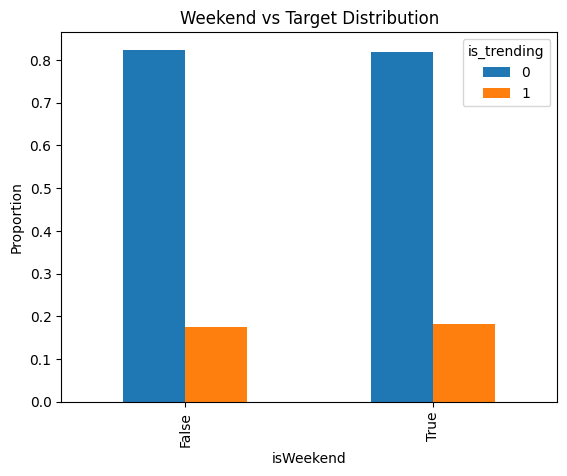

In [64]:
ct = pd.crosstab(df['isWeekend'], df[TARGET_COLUMN], normalize='index')

ct.plot(kind='bar')
plt.ylabel('Proportion')
plt.title('Weekend vs Target Distribution')
plt.show()

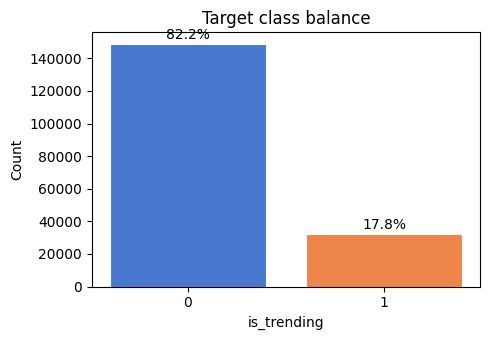

In [65]:
counts = df[TARGET_COLUMN].value_counts()
pct    = df[TARGET_COLUMN].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(counts.index.astype(str), counts.values,
              color=sns.color_palette("muted", 2), edgecolor="white", linewidth=0.8)
for bar, p in zip(bars, pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.01,
            f"{p:.1f}%", ha="center", va="bottom", fontsize=10)
ax.set_title("Target class balance")
ax.set_xlabel(TARGET_COLUMN); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

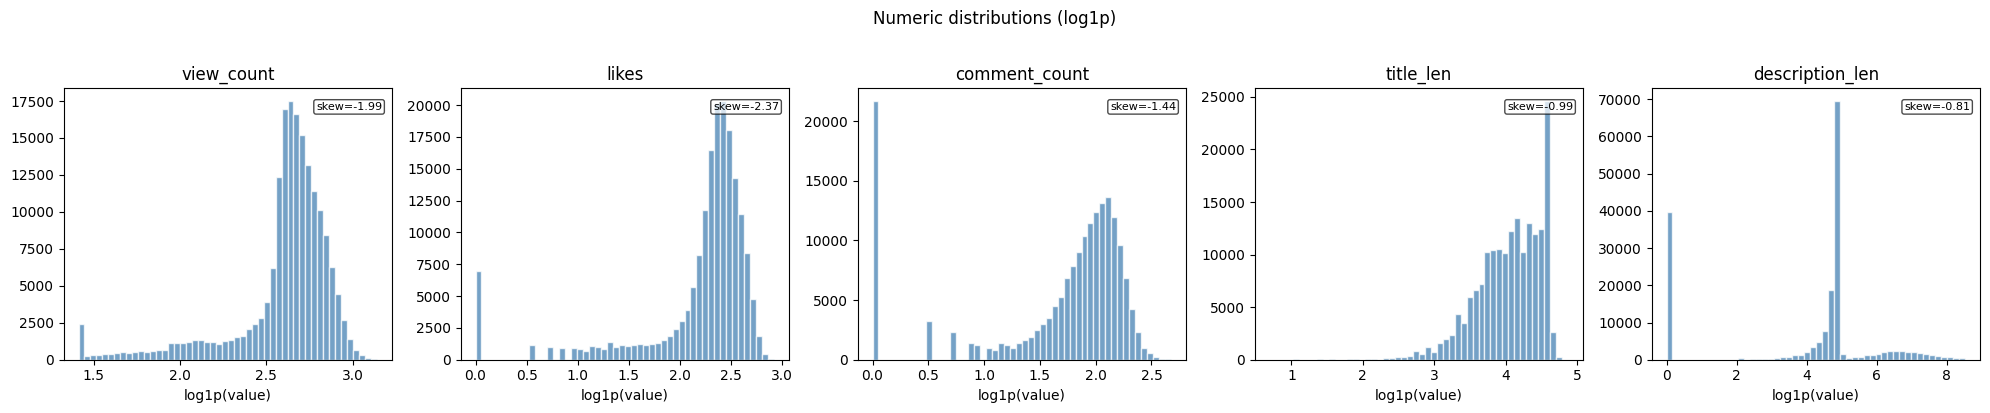

In [66]:
n = len(NUMERIC_COLUMNS)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
for ax, col in zip(axes, NUMERIC_COLUMNS):
    data = df[col].dropna()
    log_data = np.log1p(data)
    ax.hist(log_data, bins=50, color="steelblue", alpha=0.75, edgecolor="white")
    ax.set_title(col); ax.set_xlabel("log1p(value)")
    skew = stats.skew(log_data)
    ax.text(0.97, 0.95, f"skew={skew:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
plt.suptitle("Numeric distributions (log1p)", y=1.02)
plt.tight_layout(); plt.show()

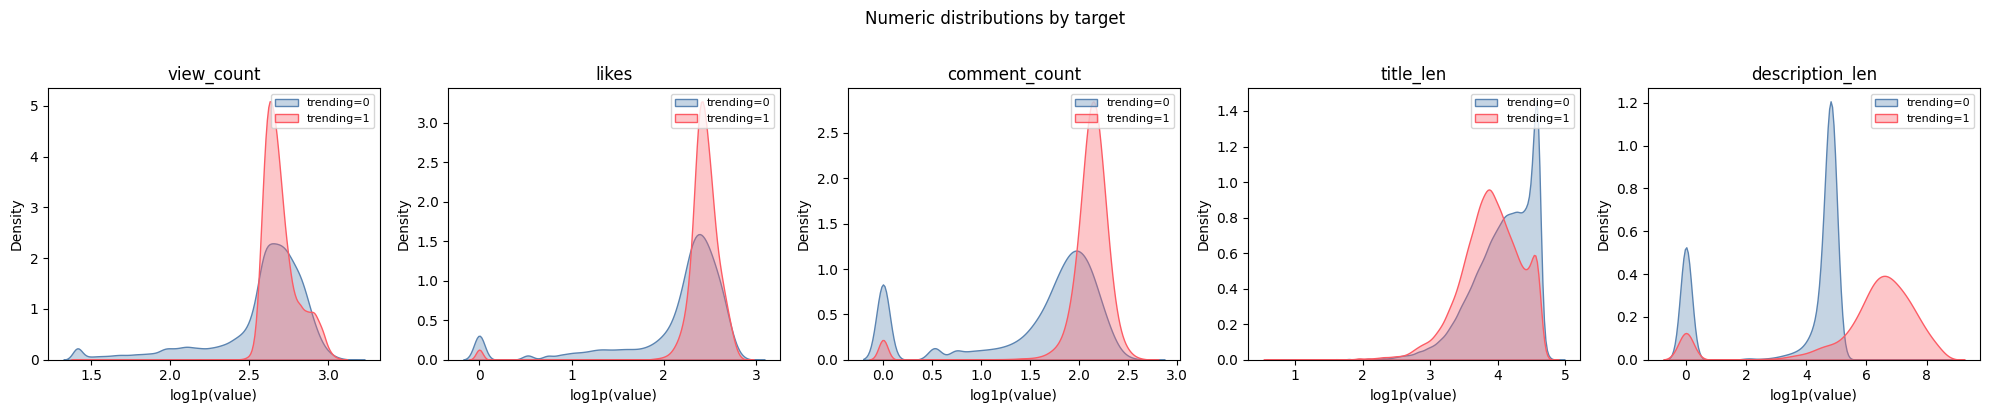

In [67]:
n = len(NUMERIC_COLUMNS)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
palette = {0: "#5b84b1", 1: "#fc5c65"}
for ax, col in zip(axes, NUMERIC_COLUMNS):
    for label, grp in df.groupby(TARGET_COLUMN):
        sns.kdeplot(np.log1p(grp[col].dropna()),
                    ax=ax, fill=True, alpha=0.35,
                    label=f"trending={label}", color=palette[label])
    ax.set_title(col); ax.set_xlabel("log1p(value)")
    ax.legend(fontsize=8)
plt.suptitle("Numeric distributions by target", y=1.02)
plt.tight_layout(); plt.show()

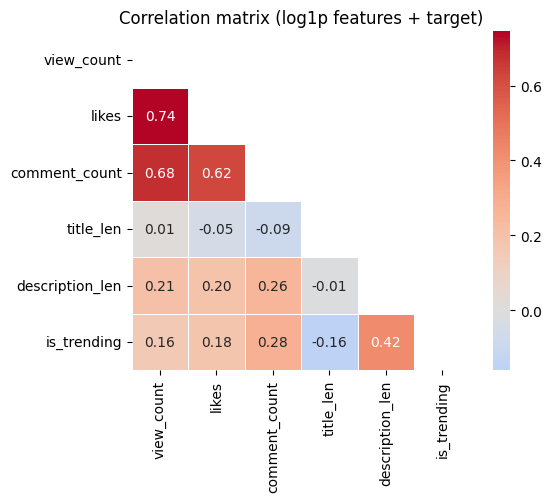

In [68]:
cols = NUMERIC_COLUMNS + [TARGET_COLUMN]
corr = df[cols].apply(np.log1p).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            square=True, ax=ax)
ax.set_title("Correlation matrix (log1p features + target)")
plt.tight_layout(); plt.show()

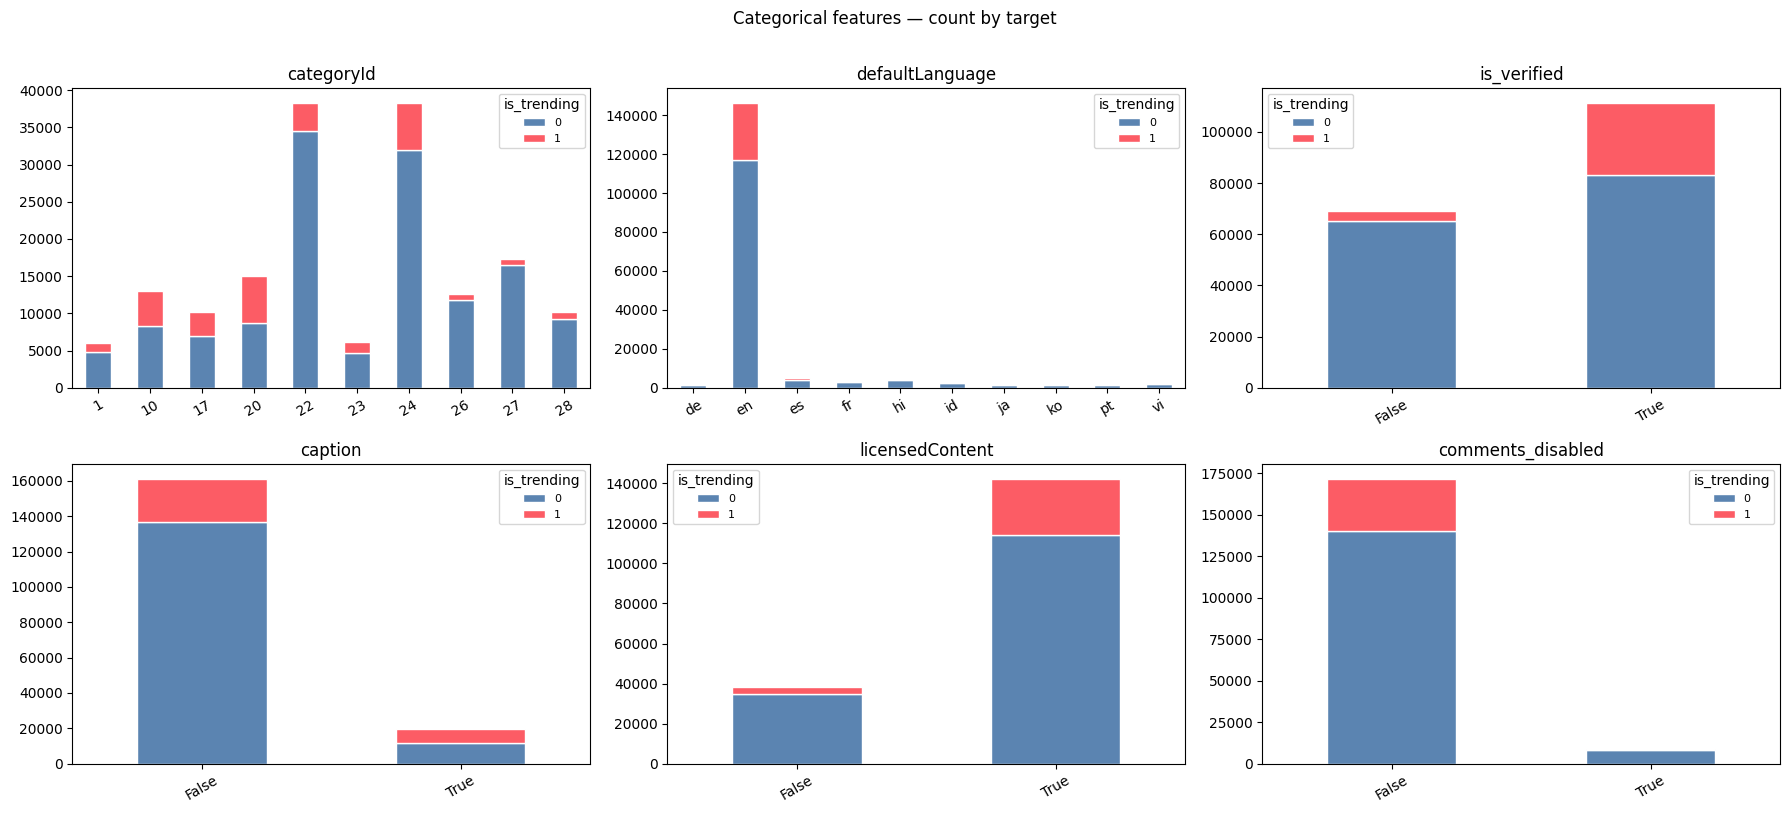

In [69]:
ncols = 3
nrows = -(-len(CATEGORICAL_COLUMNS) // ncols)
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(6 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLUMNS):
    ax = axes[i]
    top = df[col].value_counts().head(10).index
    pivot = (df[df[col].isin(top)]
               .groupby([col, TARGET_COLUMN])
               .size().unstack(fill_value=0))
    pivot.plot(kind="bar", stacked=True, ax=ax,
               color=["#5b84b1", "#fc5c65"], edgecolor="white")
    ax.set_title(col); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title=TARGET_COLUMN, fontsize=8)

for j in range(i + 1, len(axes)): axes[j].set_visible(False)
plt.suptitle("Categorical features — count by target", y=1.01)
plt.tight_layout(); plt.show()

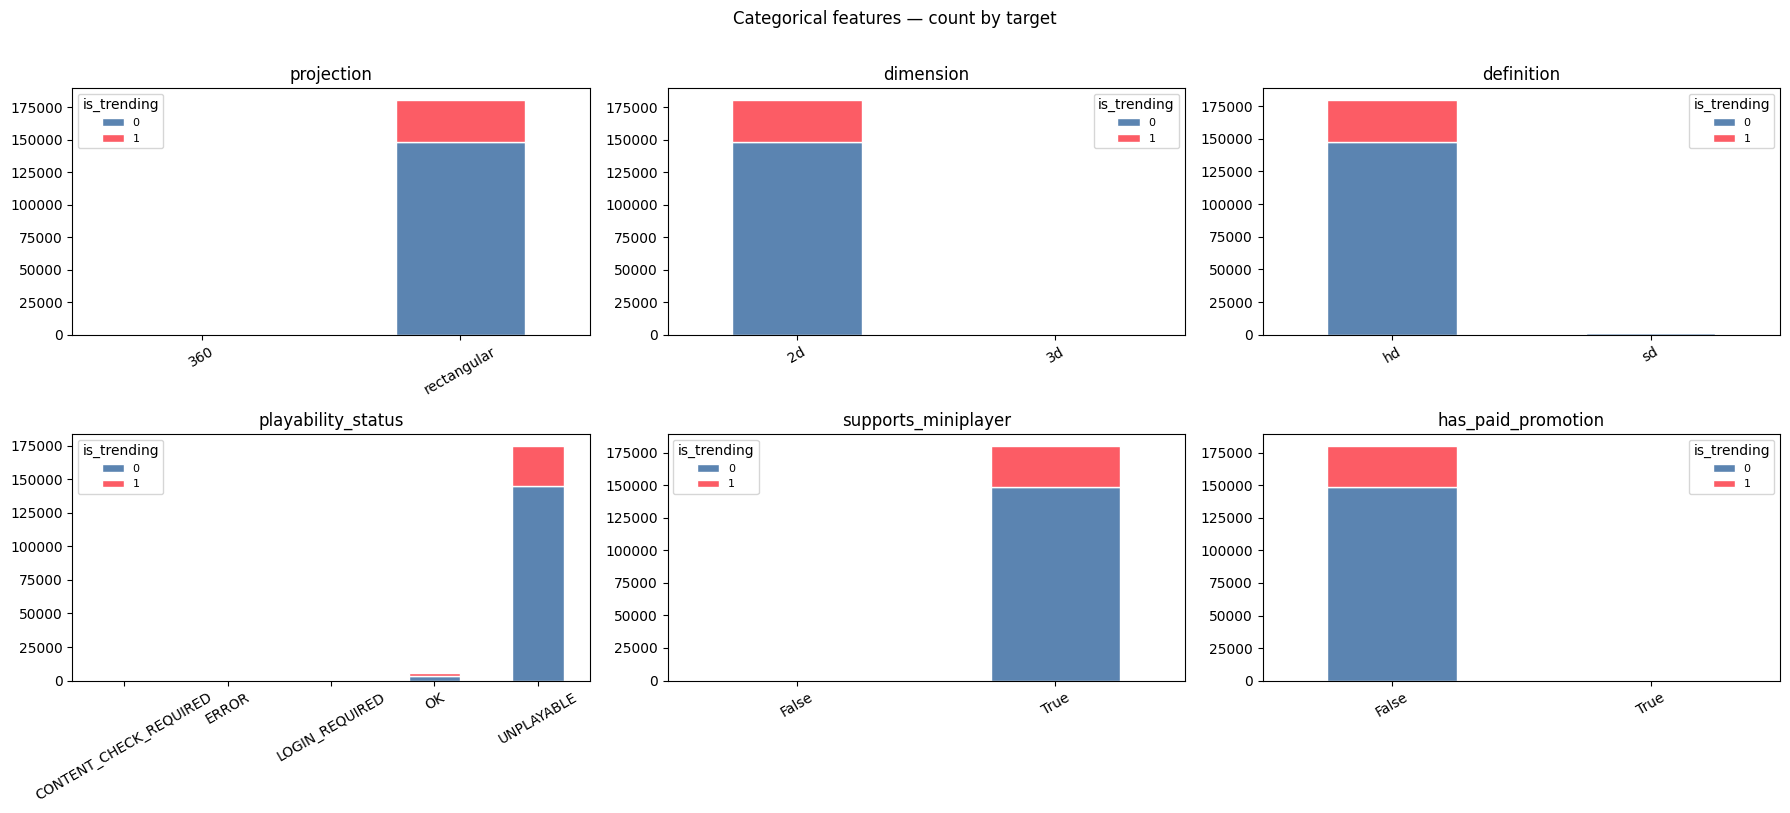

In [70]:
ncols = 3
nrows = -(-len(DROPPED_CATEGORICAL_COLUMNS) // ncols)
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(6 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(DROPPED_CATEGORICAL_COLUMNS):
    ax = axes[i]
    top = df[col].value_counts().head(10).index
    pivot = (df[df[col].isin(top)]
               .groupby([col, TARGET_COLUMN])
               .size().unstack(fill_value=0))
    pivot.plot(kind="bar", stacked=True, ax=ax,
               color=["#5b84b1", "#fc5c65"], edgecolor="white")
    ax.set_title(col); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title=TARGET_COLUMN, fontsize=8)


for j in range(i + 1, len(axes)): axes[j].set_visible(False)
plt.suptitle("Categorical features — count by target", y=1.01)
plt.tight_layout(); plt.show()

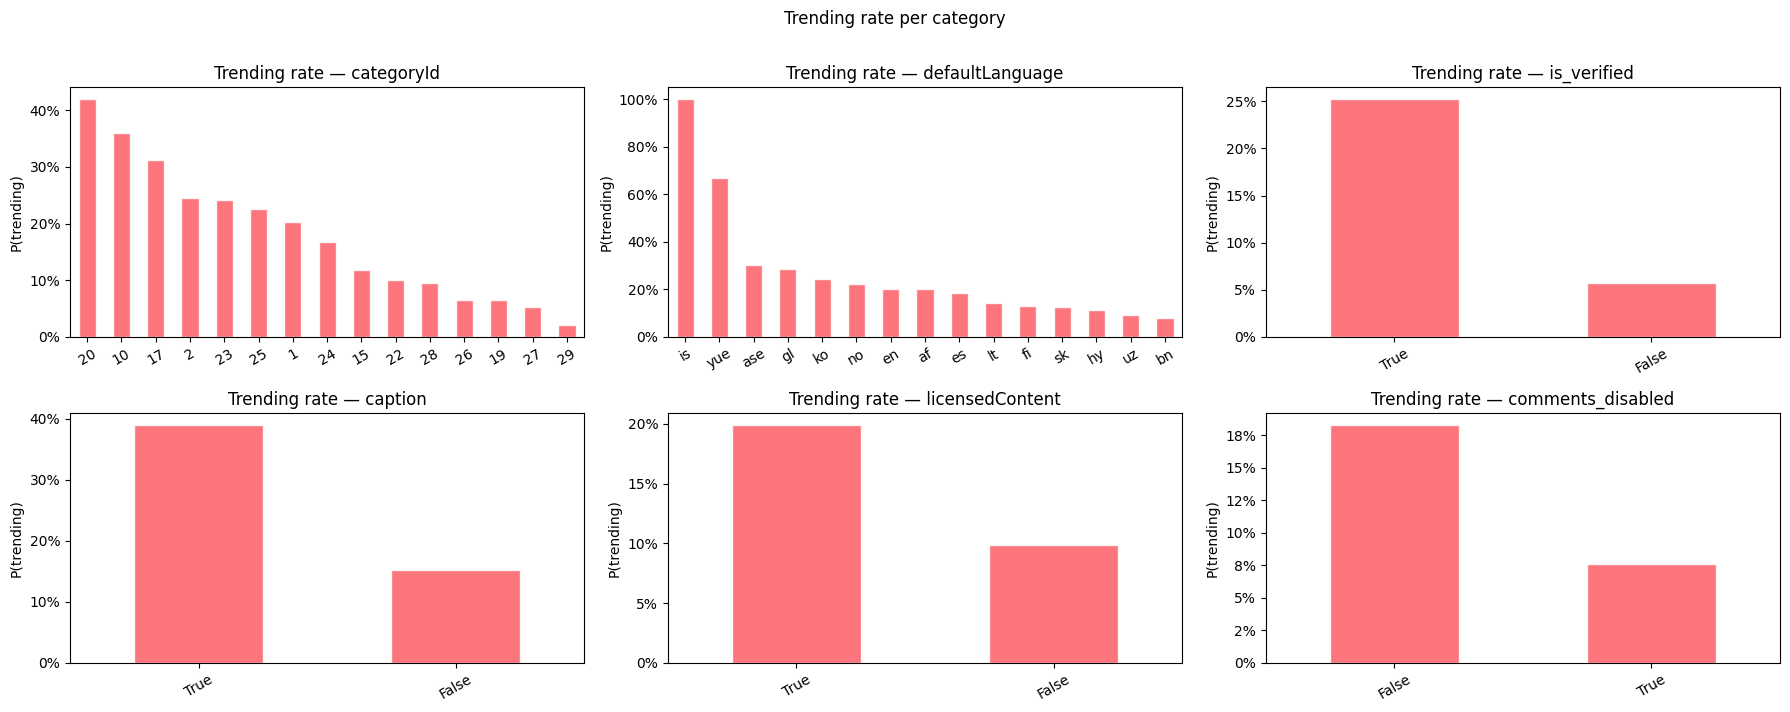

In [71]:
ncols = 3
nrows = -(-len(CATEGORICAL_COLUMNS) // ncols)
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(6 * ncols, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLUMNS):
    ax = axes[i]
    rate = (df.groupby(col)[TARGET_COLUMN].mean()
              .sort_values(ascending=False)
              .head(15))
    rate.plot(kind="bar", ax=ax, color="#fc5c65",
              edgecolor="white", alpha=0.85)
    ax.set_title(f"Trending rate — {col}")
    ax.set_ylabel("P(trending)"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

for j in range(i + 1, len(axes)): axes[j].set_visible(False)
plt.suptitle("Trending rate per category", y=1.01)
plt.tight_layout(); plt.show()

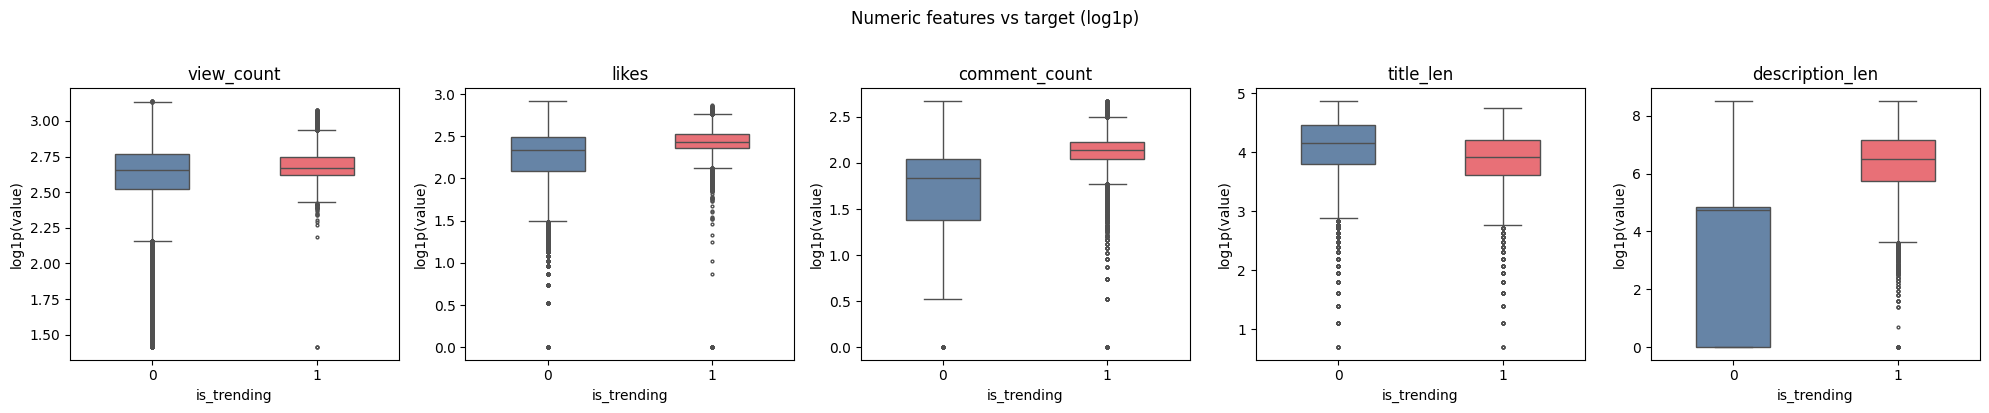

In [72]:
n = len(NUMERIC_COLUMNS)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
for ax, col in zip(axes, NUMERIC_COLUMNS):
    plot_df = df[[col, TARGET_COLUMN]].copy()
    plot_df[col] = np.log1p(plot_df[col])
    sns.boxplot(
    data=plot_df,
    x=TARGET_COLUMN,
    y=col,
    hue=TARGET_COLUMN,
    palette={0: "#5b84b1", 1: "#fc5c65"},
    width=0.45,
    fliersize=2,
    ax=ax,
    legend=False
)
    ax.set_title(col); ax.set_xlabel(TARGET_COLUMN)
    ax.set_ylabel("log1p(value)")
plt.suptitle("Numeric features vs target (log1p)", y=1.02)
plt.tight_layout(); plt.show()

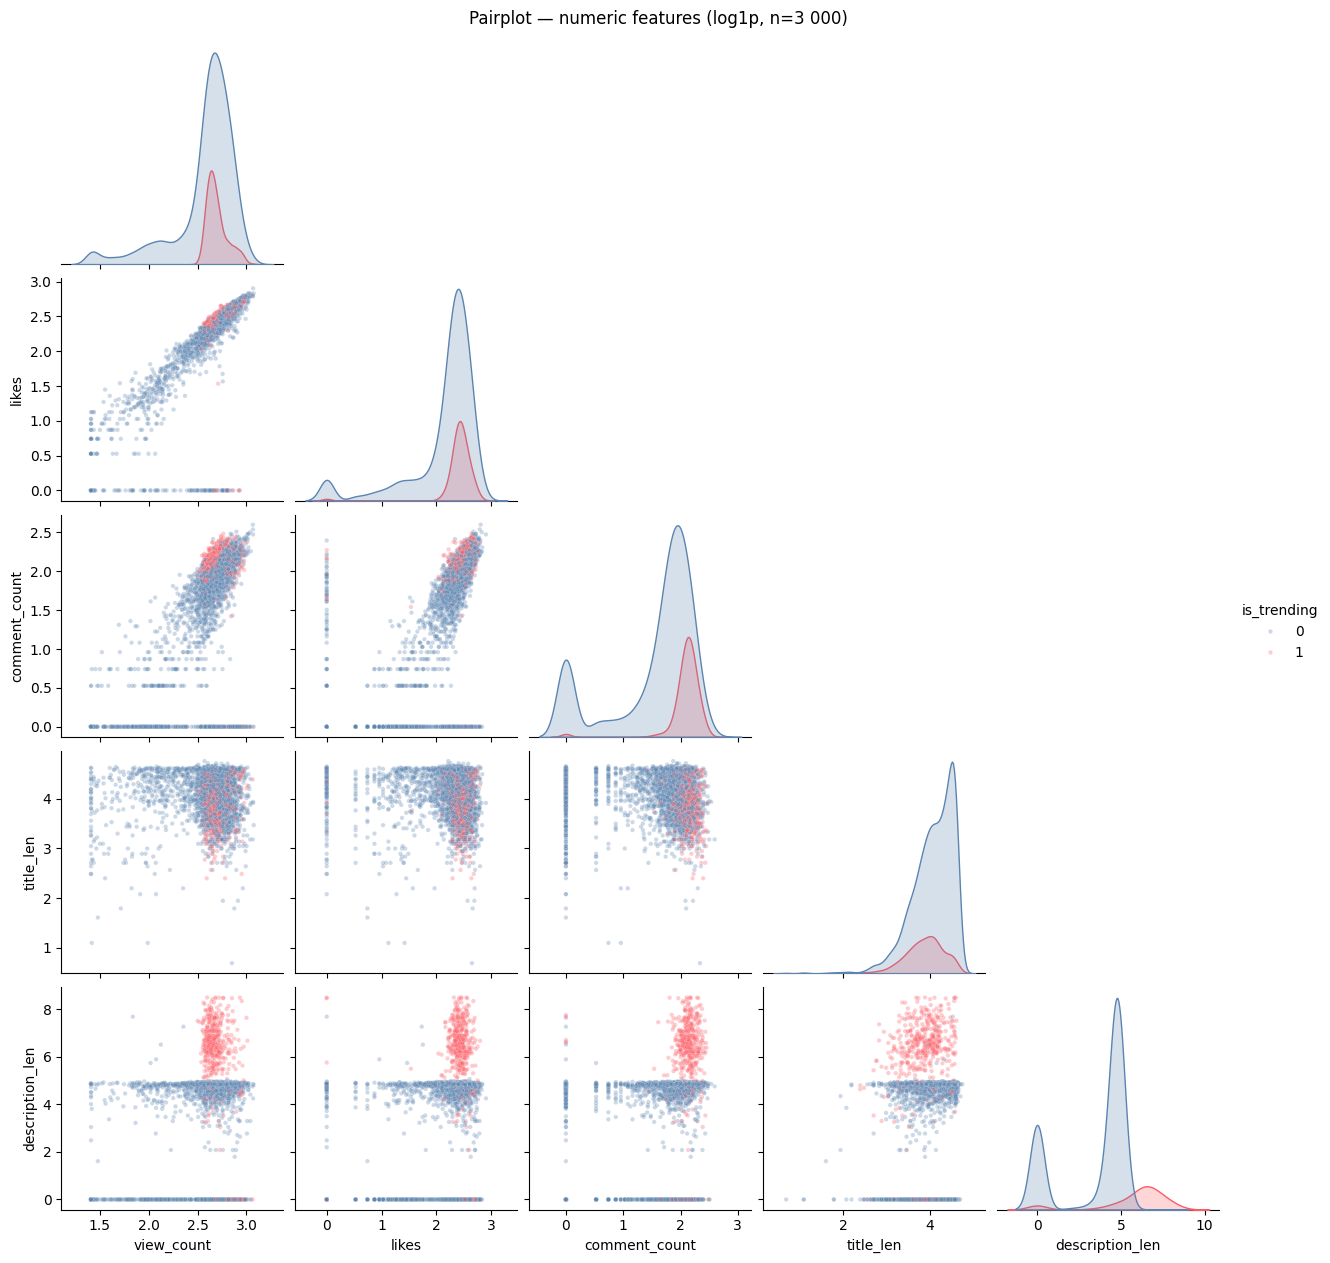

In [73]:
sample = df[NUMERIC_COLUMNS + [TARGET_COLUMN]].sample(
    n=min(3000, len(df)), random_state=42)
sample[NUMERIC_COLUMNS] = np.log1p(sample[NUMERIC_COLUMNS])

g = sns.pairplot(sample, hue=TARGET_COLUMN,
                 palette={0: "#5b84b1", 1: "#fc5c65"},
                 diag_kind="kde", plot_kws=dict(alpha=0.3, s=10),
                 corner=True)
g.figure.suptitle("Pairplot — numeric features (log1p, n=3 000)", y=1.01)
plt.show()

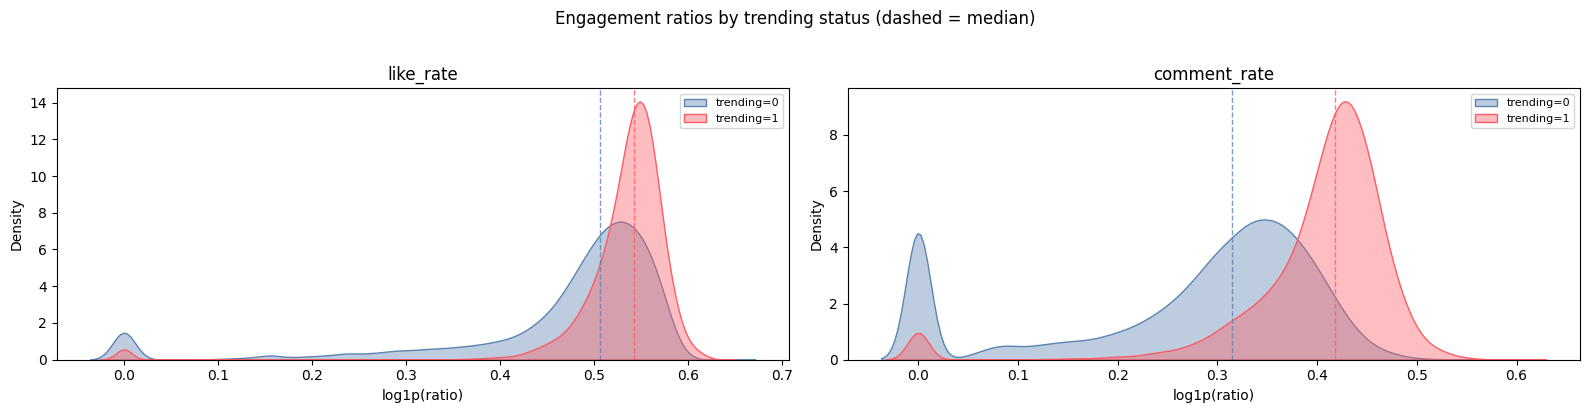

Median engagement ratios by class:
             like_rate  comment_rate
is_trending                         
0               0.6584        0.3701
1               0.7193        0.5195


In [74]:
df["like_rate"]    = df["likes"]         / (df["view_count"] + 1)
df["comment_rate"] = df["comment_count"] / (df["view_count"] + 1)

RATIO_COLS = ["like_rate", "comment_rate"]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
palette = {0: "#5b84b1", 1: "#fc5c65"}

for ax, col in zip(axes, RATIO_COLS):
    for label, grp in df.groupby(TARGET_COLUMN):
        vals = np.log1p(grp[col].clip(lower=0).dropna())
        sns.kdeplot(vals, ax=ax, fill=True, alpha=0.4,
                    label=f"trending={label}", color=palette[label])
    ax.set_title(col); ax.set_xlabel("log1p(ratio)")
    ax.legend(fontsize=8)

    # Annotate median per class
    for label, grp in df.groupby(TARGET_COLUMN):
        med = np.log1p(grp[col].clip(lower=0).median())
        ax.axvline(med, color=palette[label], linestyle="--", lw=1, alpha=0.8)

plt.suptitle("Engagement ratios by trending status (dashed = median)", y=1.02)
plt.tight_layout(); plt.show()

# Print median lift
print("Median engagement ratios by class:")
print(df.groupby(TARGET_COLUMN)[RATIO_COLS].median().round(4))

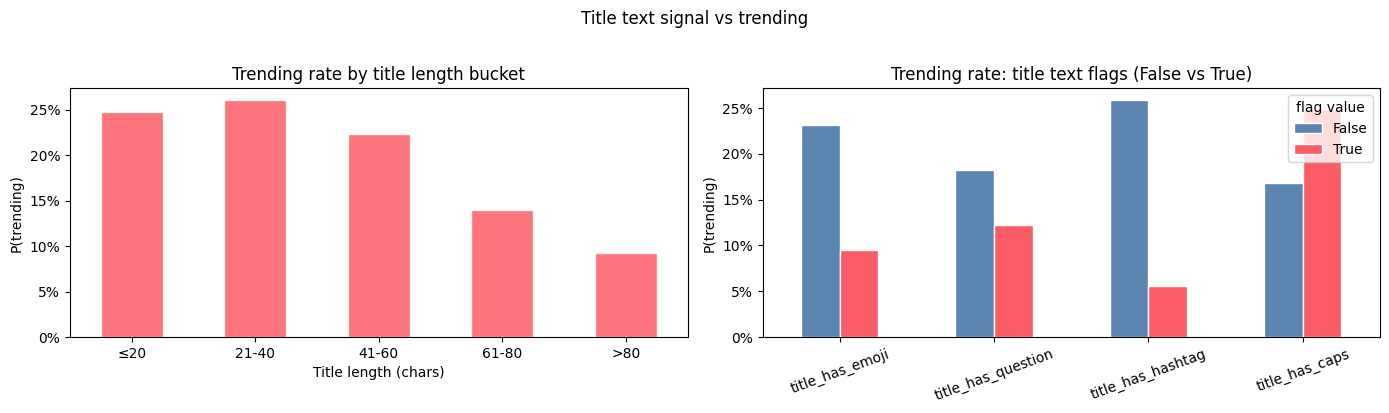

In [75]:
df["title_has_emoji"]    = df["title"].apply(lambda x: bool(
    any(ord(c) > 127 and ord(c) < 0x1F9FF or ord(c) > 0x1F300 for c in str(x))))
df["title_has_question"]  = df["title"].str.contains(r"\?", regex=True)
df["title_has_hashtag"]   = df["title"].str.contains(r"#", regex=True)
df["title_has_caps"]      = df["title"].apply(
    lambda x: sum(c.isupper() for c in str(x)) / (len(str(x)) + 1) > 0.3)
df["title_len_bin"] = pd.cut(df["title_len"],
    bins=[0,20,40,60,80,200], labels=["≤20","21-40","41-60","61-80",">80"])

text_flags = ["title_has_emoji","title_has_question","title_has_hashtag","title_has_caps"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: trending rate by title length bin
rate_by_len = df.groupby("title_len_bin", observed=True)[TARGET_COLUMN].mean()
rate_by_len.plot(kind="bar", ax=axes[0], color="#fc5c65", edgecolor="white", alpha=0.85)
axes[0].set_title("Trending rate by title length bucket")
axes[0].set_ylabel("P(trending)"); axes[0].set_xlabel("Title length (chars)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[0].tick_params(axis="x", rotation=0)

# Right: trending rate by text flag
flag_rates = {f: df.groupby(f)[TARGET_COLUMN].mean() for f in text_flags}
flag_df = pd.DataFrame(flag_rates).T
flag_df.plot(kind="bar", ax=axes[1],
             color=["#5b84b1", "#fc5c65"], edgecolor="white")
axes[1].set_title("Trending rate: title text flags (False vs True)")
axes[1].set_ylabel("P(trending)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="flag value")

plt.suptitle("Title text signal vs trending", y=1.02)
plt.tight_layout(); plt.show()

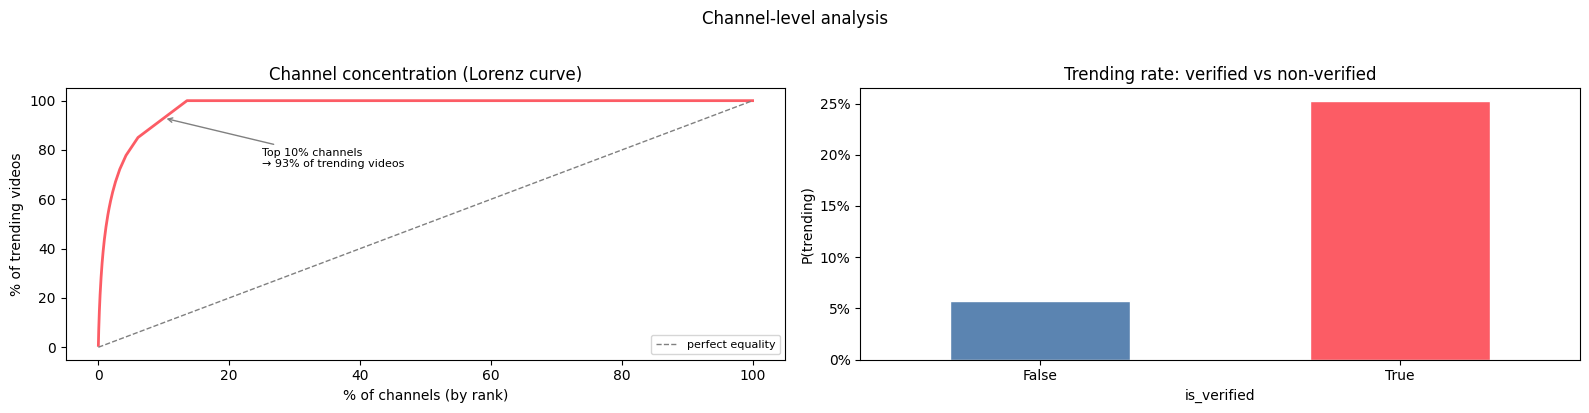

In [76]:
# ── Channel-level signals ────────────────────────────────────────────────
channel_stats = df.groupby("channelId").agg(
    video_count  = ("video_id",  "count"),
    trending_count = (TARGET_COLUMN, "sum"),
    trending_rate  = (TARGET_COLUMN, "mean"),
    avg_views    = ("view_count", "mean"),
    is_verified  = ("is_verified", "first")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ranked = channel_stats.sort_values("trending_count", ascending=False)
ranked["cum_pct_channels"]  = np.arange(1, len(ranked)+1) / len(ranked) * 100
ranked["cum_pct_trending"] = ranked["trending_count"].cumsum() / ranked["trending_count"].sum() * 100
axes[0].plot(ranked["cum_pct_channels"], ranked["cum_pct_trending"], color="#fc5c65", lw=2)
axes[0].plot([0,100],[0,100], "--", color="gray", lw=1, label="perfect equality")
axes[0].set_xlabel("% of channels (by rank)")
axes[0].set_ylabel("% of trending videos")
axes[0].set_title("Channel concentration (Lorenz curve)")
axes[0].legend(fontsize=8)

# Find top-N% stat
top10_pct = ranked.head(int(len(ranked)*0.1))["trending_count"].sum() / ranked["trending_count"].sum() * 100
axes[0].annotate(f"Top 10% channels\n→ {top10_pct:.0f}% of trending videos",
               xy=(10, top10_pct), xytext=(25, top10_pct - 20),
               arrowprops=dict(arrowstyle="->", color="gray"), fontsize=8)

# 2. Verified vs non-verified trending rate
ver_rate = df.groupby("is_verified")[TARGET_COLUMN].mean()
ver_rate.plot(kind="bar", ax=axes[1],
              color=["#5b84b1", "#fc5c65"], edgecolor="white", width=0.5)
axes[1].set_title("Trending rate: verified vs non-verified")
axes[1].set_ylabel("P(trending)"); axes[1].set_xlabel("is_verified")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("Channel-level analysis", y=1.02)
plt.tight_layout(); plt.show()

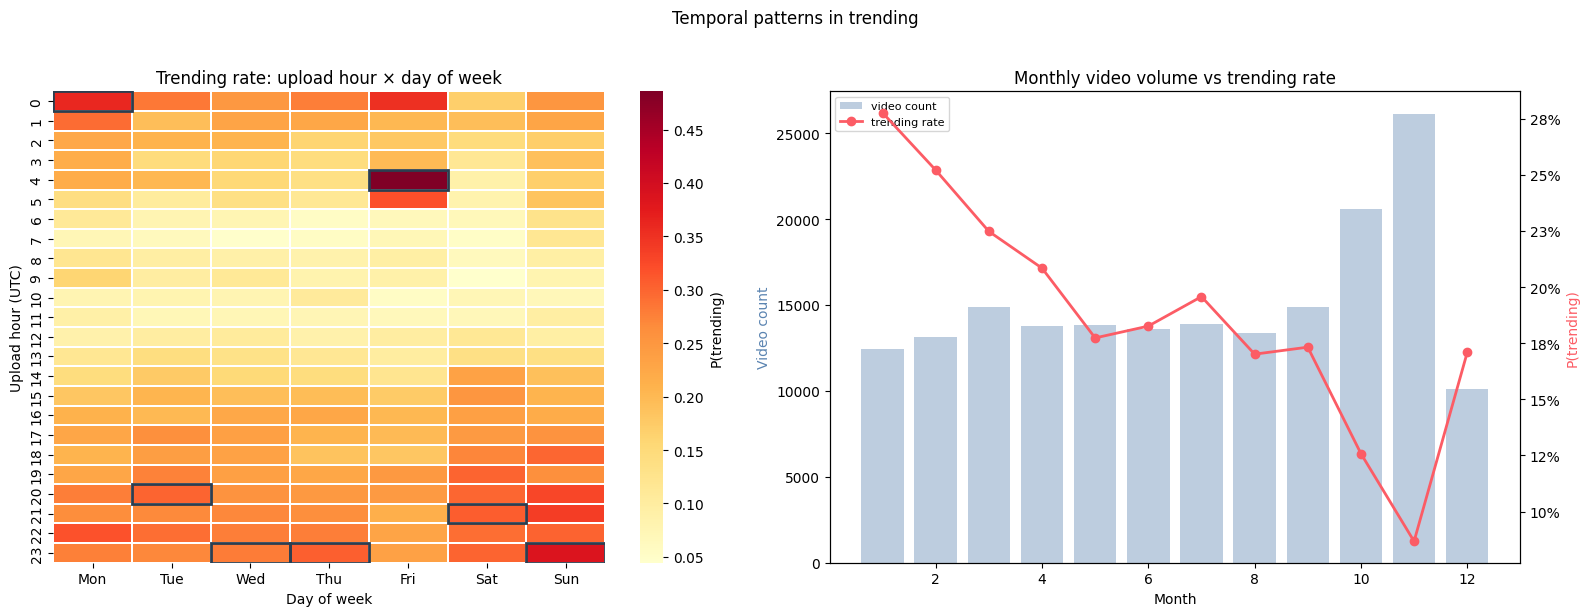

In [77]:
# ── Hour × weekday interaction heatmap ──────────────────────────────────
pivot_time = df.pivot_table(
    values=TARGET_COLUMN, index="hour", columns="weekday", aggfunc="mean")

day_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
pivot_time.columns = [day_labels[d] for d in pivot_time.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(pivot_time, cmap="YlOrRd", annot=False,
            linewidths=0.3, ax=axes[0], cbar_kws={"label": "P(trending)"})
axes[0].set_title("Trending rate: upload hour × day of week")
axes[0].set_xlabel("Day of week"); axes[0].set_ylabel("Upload hour (UTC)")

# Mark the peak hour per day
for col_idx, day in enumerate(pivot_time.columns):
    best_hour = pivot_time[day].idxmax()
    row_idx   = list(pivot_time.index).index(best_hour)
    axes[0].add_patch(plt.Rectangle((col_idx, row_idx), 1, 1,
                                     fill=False, edgecolor="#2c3e50", lw=2))

# Right: monthly trending rate with volume overlay
monthly = df.groupby("month").agg(
    trending_rate=(TARGET_COLUMN, "mean"),
    video_count=("video_id", "count")
)
ax2  = axes[1]
ax2b = ax2.twinx()

ax2.bar(monthly.index, monthly["video_count"],
        color="#5b84b1", alpha=0.4, label="video count")
ax2b.plot(monthly.index, monthly["trending_rate"],
          color="#fc5c65", marker="o", lw=2, label="trending rate")
ax2.set_xlabel("Month"); ax2.set_ylabel("Video count", color="#5b84b1")
ax2b.set_ylabel("P(trending)", color="#fc5c65")
ax2.set_title("Monthly video volume vs trending rate")
ax2b.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
lines1, lab1 = ax2.get_legend_handles_labels()
lines2, lab2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, lab1+lab2, fontsize=8)

plt.suptitle("Temporal patterns in trending", y=1.02)
plt.tight_layout(); plt.show()

In [78]:
df["view_original"] = np.expm1(df["view_count"])


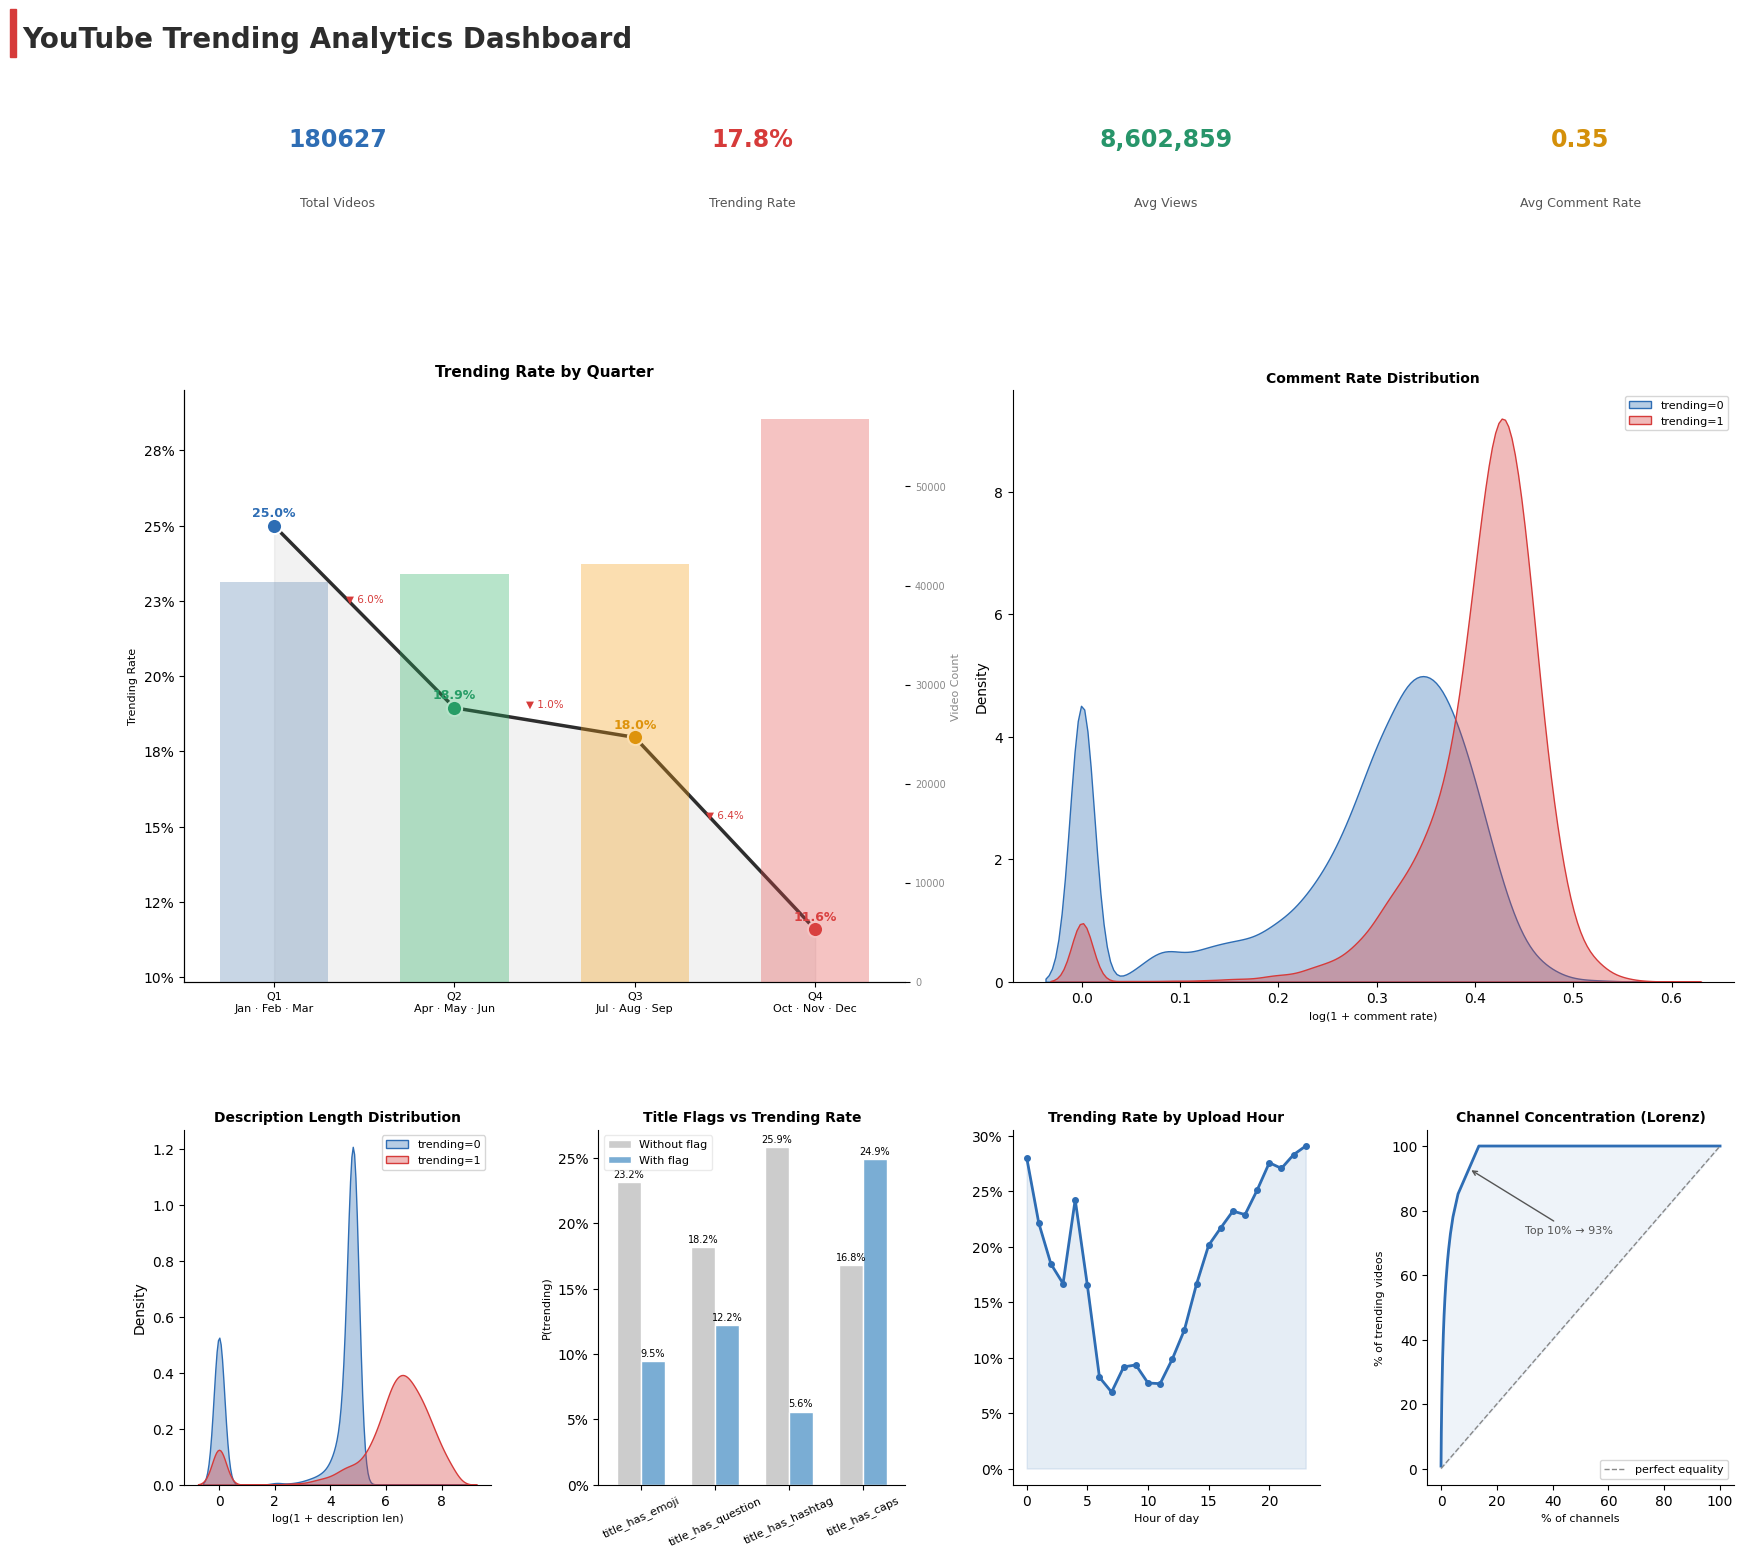

Dashboard saved → eda_dashboard.png


In [79]:
# ── EDA Dashboard ─────────────────────────────────────────────
PALETTE = {
    "blue":       "#2E6DB4",   
    "red":        "#D63B3A",   
    "green":      "#27956A",   
    "amber":      "#D4900A",   
    "gray":       "#888888",
    "light_blue": "#7AADD4",   
    "light_gray": "#CCCCCC",   
    "text":       "#2d2d2d",
    "subtext":    "#555555",
}

fig = plt.figure(figsize=(20, 16))

# ── Title block ───────────────────────────────────────────────
fig.add_artist(plt.Rectangle(
    (0.038, 0.962), 0.003, 0.030,
    transform=fig.transFigure, color=PALETTE["red"], clip_on=False
))
fig.text(0.044, 0.982, "YouTube Trending Analytics Dashboard",
         fontsize=20, fontweight="bold", va="top", color=PALETTE["text"])

# ── GridSpec ──────────────────────────────────────────────────
gs = fig.add_gridspec(3, 4,
                      top=0.95, bottom=0.07,
                      hspace=0.40, wspace=0.35,
                      height_ratios=[0.7, 2.5, 1.5]) 

# ── Row 0: KPI Cards ──────────────────────────────────────────
kpis = {
    "Total Videos":     len(df),
    "Trending Rate":    f"{df[TARGET_COLUMN].mean():.1%}",
    "Avg Views":        f"{df['view_original'].mean():,.0f}",
    "Avg Comment Rate": f"{df['comment_rate'].mean():.2f}"
}
kpi_bg     = ["#EAF2FB", "#FDECEA", "#EAF7F1", "#FEF8EC"]
kpi_accent = [PALETTE["blue"], PALETTE["red"], PALETTE["green"], PALETTE["amber"]]

for i, ((title, value), bg, acc) in enumerate(zip(kpis.items(), kpi_bg, kpi_accent)):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(bg)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.text(0.5, 0.62, value,
            ha="center", va="center",
            fontsize=17, fontweight="bold", color=acc)
    ax.text(0.5, 0.24, title,
            ha="center", va="center",
            fontsize=9, color=PALETTE["subtext"])
    for spine in ["top", "bottom", "left", "right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_edgecolor(acc)
        ax.spines[spine].set_linewidth(1.0)

# ── Row 1, col 0-1: Quarter trending ─────────────────────────
ax5 = fig.add_subplot(gs[1, :2])
mean_vals  = df.groupby("quarter")[TARGET_COLUMN].mean()
count_vals = df.groupby("quarter")["video_id"].count()

quarter_months = {1: "Jan · Feb · Mar", 2: "Apr · May · Jun",
                  3: "Jul · Aug · Sep", 4: "Oct · Nov · Dec"}
quarter_colors = [PALETTE["blue"], PALETTE["green"], PALETTE["amber"], PALETTE["red"]]

ax5b = ax5.twinx()
ax5b.bar(count_vals.index, count_vals.values,
         color=[c + "55" for c in ["#5b84b1","#27ae60","#f39c12","#e24b4a"]],
         width=0.6, zorder=1)
ax5b.set_ylabel("Video Count", fontsize=8, color=PALETTE["gray"])
ax5b.tick_params(axis="y", labelcolor=PALETTE["gray"], labelsize=7)
ax5b.spines[["top", "right"]].set_visible(False)

ax5.plot(mean_vals.index, mean_vals.values,
         lw=2.5, zorder=3, color=PALETTE["text"], marker="o", ms=0)

for q, v in mean_vals.items():
    ax5.scatter(q, v, s=120, color=quarter_colors[q-1],
                zorder=4, edgecolors="white", linewidths=1.5)

ax5.fill_between(mean_vals.index, mean_vals.values,
                 alpha=0.06, color=PALETTE["text"], zorder=2)

for q, v in mean_vals.items():
    ax5.text(q, v + 0.003, f"{v:.1%}",
             ha="center", fontsize=9, fontweight="bold",
             color=quarter_colors[q-1])

for i in range(1, len(mean_vals)):
    q_prev, q_curr = mean_vals.index[i-1], mean_vals.index[i]
    delta = mean_vals[q_curr] - mean_vals[q_prev]
    mid_x = (q_prev + q_curr) / 2
    mid_y = (mean_vals[q_prev] + mean_vals[q_curr]) / 2
    arrow = "▲" if delta >= 0 else "▼"
    col   = PALETTE["green"] if delta >= 0 else PALETTE["red"]
    ax5.text(mid_x, mid_y + 0.005, f"{arrow} {abs(delta):.1%}",
             ha="center", fontsize=7.5, color=col)

ax5.set_title("Trending Rate by Quarter", fontsize=11, fontweight="bold", pad=10)
ax5.set_ylabel("Trending Rate", fontsize=8)
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax5.set_xticks(mean_vals.index)
ax5.set_xticklabels([f"Q{q}\n{quarter_months[q]}" for q in mean_vals.index], fontsize=8)
ax5.spines[["top", "right"]].set_visible(False)
ax5.set_xlim(0.5, 4.5)
y_min, y_max = mean_vals.min(), mean_vals.max()
ax5.set_ylim(y_min * 0.85, y_max * 1.18)

# ── Row 1, col 2-3: Comment rate KDE ─────────────────────────
ax6 = fig.add_subplot(gs[1, 2:])
kde_colors = [PALETTE["blue"], PALETTE["red"]]
for (label, grp), col in zip(df.groupby(TARGET_COLUMN), kde_colors):
    sns.kdeplot(np.log1p(grp["comment_rate"].clip(lower=0)),
                ax=ax6, fill=True, alpha=0.35, color=col,
                label=f"trending={label}")
ax6.set_title("Comment Rate Distribution", fontsize=10, fontweight="bold")
ax6.set_xlabel("log(1 + comment rate)", fontsize=8)
ax6.legend(fontsize=8)
ax6.spines[["top", "right"]].set_visible(False)

# ── Row 2, col 0: Description length KDE ─────────────────────
ax1 = fig.add_subplot(gs[2, 0])
for (label, grp), col in zip(df.groupby(TARGET_COLUMN), kde_colors):
    sns.kdeplot(np.log1p(grp["description_len"].clip(lower=0)),
                ax=ax1, fill=True, alpha=0.35, color=col,
                label=f"trending={label}")
ax1.set_title("Description Length Distribution", fontsize=10, fontweight="bold")
ax1.set_xlabel("log(1 + description len)", fontsize=8)
ax1.legend(fontsize=8)
ax1.spines[["top", "right"]].set_visible(False)

# ── Row 2, col 1: Title flags bar ────────────────────────────
ax2 = fig.add_subplot(gs[2, 1])
flag_rates = {f: df.groupby(f)[TARGET_COLUMN].mean() for f in text_flags}
flag_df = pd.DataFrame(flag_rates).T
flag_df.plot(kind="bar", ax=ax2,
             color=[PALETTE["light_gray"], PALETTE["light_blue"]],
             edgecolor="white", width=0.65)
ax2.set_title("Title Flags vs Trending Rate", fontsize=10, fontweight="bold")
ax2.set_ylabel("P(trending)", fontsize=8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax2.tick_params(axis="x", rotation=25, labelsize=8)
ax2.legend(["Without flag", "With flag"], fontsize=8, framealpha=0.4)
ax2.spines[["top", "right"]].set_visible(False)
for container in ax2.containers:
    ax2.bar_label(container, fmt="{:.1%}".format,
                  label_type="edge", fontsize=7, padding=2)

# ── Row 2, col 2: Trending rate by hour ──────────────────────
ax3 = fig.add_subplot(gs[2, 2])
hour_rate = df.groupby("hour")[TARGET_COLUMN].mean()
ax3.plot(hour_rate.index, hour_rate.values,
         marker="o", ms=4, color=PALETTE["blue"], lw=2)
ax3.fill_between(hour_rate.index, hour_rate.values,
                 alpha=0.12, color=PALETTE["blue"])
ax3.set_title("Trending Rate by Upload Hour", fontsize=10, fontweight="bold")
ax3.set_xlabel("Hour of day", fontsize=8)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax3.spines[["top", "right"]].set_visible(False)

# ── Row 2, col 3: Lorenz curve ────────────────────────────────
ax4 = fig.add_subplot(gs[2, 3])
ranked = channel_stats.sort_values("trending_count", ascending=False)
ranked["cum_pct_channels"] = np.arange(1, len(ranked) + 1) / len(ranked) * 100
ranked["cum_pct_trending"] = ranked["trending_count"].cumsum() / ranked["trending_count"].sum() * 100
ax4.plot(ranked["cum_pct_channels"], ranked["cum_pct_trending"],
         lw=2, color=PALETTE["blue"])
ax4.plot([0, 100], [0, 100], "--", lw=1,
         color=PALETTE["gray"], label="perfect equality")
ax4.fill_between(ranked["cum_pct_channels"],
                 ranked["cum_pct_trending"],
                 ranked["cum_pct_channels"],
                 alpha=0.08, color=PALETTE["blue"])
ax4.set_title("Channel Concentration (Lorenz)", fontsize=10, fontweight="bold")
ax4.set_xlabel("% of channels", fontsize=8)
ax4.set_ylabel("% of trending videos", fontsize=8)
ax4.legend(fontsize=8)
ax4.spines[["top", "right"]].set_visible(False)
top10_pct = ranked.head(int(len(ranked) * 0.1))["trending_count"].sum() / ranked["trending_count"].sum() * 100
ax4.annotate(f"Top 10% → {top10_pct:.0f}%",
             xy=(10, top10_pct), xytext=(30, top10_pct - 20),
             arrowprops=dict(arrowstyle="->", color=PALETTE["subtext"]),
             fontsize=8, color=PALETTE["subtext"])

plt.savefig("eda_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved → eda_dashboard.png")